In [21]:
import math
import typing as ty

import torch
import numpy as np
import pandas as pd
import random
import re
import matplotlib as plt
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, LabelEncoder
from ucimlrepo import fetch_ucirepo
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from typing import Optional, Union
import delu
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import mahalanobis

import faiss
import faiss.contrib.torch_utils

import warnings
warnings.filterwarnings('ignore')


# Задание 2. 3 балла

Возьмите метод TabR из той же библиотеки (лекция 7, слайды 26-28. Статья: https://arxiv.org/pdf/2307.14338). Обучите его на 2-3 датасетах (можно взять те же самые, что и в предыдущем задании или другие из этой библиотеки). Сравните, насколько сильно ближайшие соседи в скрытом пространстве (после encoder) в среднем отличаются от ближайших соседей (те же самые соседи получаются или нет) в изначальном пространстве (естественно со стандартизацией) по Евклидовой метрике/Метрике махалонобиса. Возможно, для каких-то сэмплов эта разница более выражена, попытайтесь охарактеризовать эти сэмплы (возможно, это выбросы или сэмплы этого лейбла, но сильно непохожие на данный и т.п.)

In [6]:
from utilstabr import make_module
# adapted from https://github.com/yandex-research/tabular-dl-tabr/blob/main/bin/tabr.py

class TabR(nn.Module):
    def __init__(
        self,
        *,
        #
        n_num_features: int,
        n_cat_features: int,
        n_classes: Optional[int],
        #
        num_embeddings: Optional[dict],  # lib.deep.ModuleSpec
        d_main: int,
        d_multiplier: float,
        encoder_n_blocks: int,
        predictor_n_blocks: int,
        mixer_normalization,
        context_dropout: float,
        dropout0: float,
        dropout1,
        normalization: str,
        activation: str,
        #
        # The following options should be used only when truly needed.
        memory_efficient: bool = False,
        candidate_encoding_batch_size: Optional[int] = None,
    ) -> None:
        if not memory_efficient:
            assert candidate_encoding_batch_size is None
        if mixer_normalization == 'auto':
            mixer_normalization = encoder_n_blocks > 0
        if encoder_n_blocks == 0:
            assert not mixer_normalization
        super().__init__()
        if dropout1 == 'dropout0':
            dropout1 = dropout0
        self.n_classes = n_classes

        self.num_embeddings = (
            None
            if num_embeddings is None
            else make_module(num_embeddings, n_features=n_num_features)
        )

        # >>> E
        d_in = (
            n_num_features
            * (1 if num_embeddings is None else num_embeddings['d_embedding'])
            + n_cat_features
        )
        d_block = int(d_main * d_multiplier)
        Normalization = getattr(nn, normalization)
        Activation = getattr(nn, activation)

        def make_block(prenorm: bool) -> nn.Sequential:
            return nn.Sequential(
                *([Normalization(d_main)] if prenorm else []),
                nn.Linear(d_main, d_block),
                Activation(),
                nn.Dropout(dropout0),
                nn.Linear(d_block, d_main),
                nn.Dropout(dropout1),
            )

        self.linear = nn.Linear(d_in, d_main)
        self.blocks0 = nn.ModuleList(
            [make_block(i > 0) for i in range(encoder_n_blocks)]
        )

        # >>> R
        self.normalization = Normalization(d_main) if mixer_normalization else None
        self.label_encoder = (
            nn.Linear(1, d_main)
            if n_classes == 1
            else nn.Sequential(
                nn.Embedding(n_classes, d_main), delu.nn.Lambda(lambda x: x.squeeze(-2))
            )
        )
        self.K = nn.Linear(d_main, d_main)
        self.T = nn.Sequential(
            nn.Linear(d_main, d_block),
            Activation(),
            nn.Dropout(dropout0),
            nn.Linear(d_block, d_main, bias=False),
        )
        self.dropout = nn.Dropout(context_dropout)

        # >>> P
        self.blocks1 = nn.ModuleList(
            [make_block(True) for _ in range(predictor_n_blocks)]
        )
        self.head = nn.Sequential(
            Normalization(d_main),
            Activation(),
            nn.Linear(d_main, n_classes),
        )

        # >>>
        self.search_index = None
        self.memory_efficient = memory_efficient
        self.candidate_encoding_batch_size = candidate_encoding_batch_size
        self.reset_parameters()

    def reset_parameters(self):
        if isinstance(self.label_encoder, nn.Linear):
            bound = 1 / math.sqrt(2.0)
            nn.init.uniform_(self.label_encoder.weight, -bound, bound)  # type: ignore[code]  # noqa: E501
            nn.init.uniform_(self.label_encoder.bias, -bound, bound)  # type: ignore[code]  # noqa: E501
        else:
            assert isinstance(self.label_encoder[0], nn.Embedding)
            nn.init.uniform_(self.label_encoder[0].weight, -1.0, 1.0)  # type: ignore[code]  # noqa: E501

    def _encode(self, x_num,x_cat) :
        x = []
        if x_num is None:
            self.num_embeddings = None
        else:
            x.append(
                x_num
                if self.num_embeddings is None
                else self.num_embeddings(x_num).flatten(1)
            )
        if x_cat is not None:
            x.append(x_cat)
        x = torch.cat(x, dim=1)


        x = self.linear(x)
        for block in self.blocks0:
            x = x + block(x)
        k = self.K(x if self.normalization is None else self.normalization(x))

        return x, k

    def forward(
        self,
        *,
        x_num: Tensor,
        x_cat: ty.Optional[Tensor],
        y: Optional[Tensor],
        candidate_x_num: ty.Optional[Tensor],
        candidate_x_cat: ty.Optional[Tensor],
        candidate_y: Tensor,
        context_size: int,
        is_train: bool,
    ) -> Tensor:
        # >>>
        with torch.set_grad_enabled(
            torch.is_grad_enabled() and not self.memory_efficient
        ):
            # NOTE: during evaluation, candidate keys can be computed just once, which
            # looks like an easy opportunity for optimization. However:
            # - if your dataset is small or/and the encoder is just a linear layer
            #   (no embeddings and encoder_n_blocks=0), then encoding candidates
            #   is not a bottleneck.
            # - implementing this optimization makes the code complex and/or unobvious,
            #   because there are many things that should be taken into account:
            #     - is the input coming from the "train" part?
            #     - is self.training True or False?
            #     - is PyTorch autograd enabled?
            #     - is saving and loading checkpoints handled correctly?
            # This is why we do not implement this optimization.

            # When memory_efficient is True, this potentially heavy computation is
            # performed without gradients.
            # Later, it is recomputed with gradients only for the context objects.
            candidate_k = (
                self._encode(candidate_x_num,candidate_x_cat)[1]
                if self.candidate_encoding_batch_size is None
                else torch.cat(
                    [
                        self._encode(x_num_,x_cat_)[1]
                        for x_num_,x_cat_ in delu.iter_batches(
                            (candidate_x_num,candidate_x_cat), self.candidate_encoding_batch_size
                        )
                    ]
                )
            )
        x, k = self._encode(x_num,x_cat)
        if is_train:
            # NOTE: here, we add the training batch back to the candidates after the
            # function `apply_model` removed them. The further code relies
            # on the fact that the first batch_size candidates come from the
            # training batch.
            assert y is not None
            candidate_k = torch.cat([k, candidate_k])
            candidate_y = torch.cat([y, candidate_y])
        else:
            assert y is None

        # >>>
        # The search below is optimized for larger datasets and is significantly faster
        # than the naive solution (keep autograd on + manually compute all pairwise
        # squared L2 distances + torch.topk).
        # For smaller datasets, however, the naive solution can actually be faster.
        batch_size, d_main = k.shape
        device = k.device
        with torch.no_grad():
            if self.search_index is None:
                self.search_index = (
                    faiss.GpuIndexFlatL2(faiss.StandardGpuResources(), d_main)
                    if device.type == 'cuda'
                    else faiss.IndexFlatL2(d_main)
                )

            # Updating the index is much faster than creating a new one.
            self.search_index.reset()
            # print(candidate_k)
            self.search_index.add(candidate_k.to(torch.float32))  # type: ignore[code]
            distances: Tensor
            context_idx: Tensor
            distances, context_idx = self.search_index.search(  # type: ignore[code]
                k.to(torch.float32), context_size + (1 if is_train else 0)
            )
            # print(context_idx)
            if is_train:
                # NOTE: to avoid leakage, the index i must be removed from the i-th row,
                # (because of how candidate_k is constructed).
                distances[
                    context_idx == torch.arange(batch_size, device=device)[:, None]
                ] = torch.inf
                # Not the most elegant solution to remove the argmax, but anyway.
                context_idx = context_idx.gather(-1, distances.argsort()[:, :-1])
                # print(context_idx)
        if self.memory_efficient and torch.is_grad_enabled():
            assert is_train
            # Repeating the same computation,
            # but now only for the context objects and with autograd on.
            context_k = self._encode(
                torch.cat([x_num, candidate_x_num])[
                        context_idx
                    ].flatten(0, 1),
                torch.cat([x_cat, candidate_x_cat])[
                        context_idx
                    ].flatten(0, 1)
            )[1].reshape(batch_size, context_size, -1)
        else:
            context_k = candidate_k[context_idx]
            # print(context_k.shape)

        # In theory, when autograd is off, the distances obtained during the search
        # can be reused. However, this is not a bottleneck, so let's keep it simple
        # and use the same code to compute `similarities` during both
        # training and evaluation.
        similarities = (
            -k.square().sum(-1, keepdim=True)
            + (2 * (k[..., None, :] @ context_k.transpose(-1, -2))).squeeze(-2)
            - context_k.square().sum(-1)
        )
        probs = F.softmax(similarities, dim=-1)
        probs = self.dropout(probs)

        if self.n_classes > 1:
            context_y_emb = self.label_encoder(candidate_y[context_idx][..., None].long())
        else:
            context_y_emb = self.label_encoder(candidate_y[context_idx][..., None])
            if len(context_y_emb.shape) == 4:
                context_y_emb = context_y_emb[:,:,0,:]
        values = context_y_emb + self.T(k[:, None] - context_k)
        context_x = (probs[:, None] @ values).squeeze(1)
        x = x + context_x

        # >>>
        for block in self.blocks1:
            x = x + block(x)
        x = self.head(x)
        return x

### Обучим на двух датасетах из предыдущего задания

In [7]:
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

X = X[:1000] # в связи с ограниченными вычислительными ресурсами
y = y[:1000]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


In [8]:
n_classes = len(np.unique(y_encoded))

model = TabR(
    n_num_features=X_train.shape[1],
    n_cat_features=0,
    n_classes=n_classes,
    num_embeddings=None,
    d_main=64,
    d_multiplier=2.0,
    encoder_n_blocks=4,  # количество блоков в энкодере
    predictor_n_blocks=4,  # количество блоков в предикторе
    mixer_normalization=True,  # нормализация в модуле поиска
    context_dropout=0.1,  # Dropout для контекста
    dropout0=0.2,
    dropout1=0.1,
    normalization='BatchNorm1d',
    activation='ReLU',
)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


epochs = 50

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(
        x_num=X_train,
        x_cat=None,
        y=y_train,
        candidate_x_num=X_train,  # кандидаты для поиска ближайших соседей
        candidate_x_cat=None,
        candidate_y=y_train,  # метки кандидатов
        context_size=32,   # кол-во ближайших соседей
        is_train=True,  # тк обучение
    )

    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    outputs = model(
        x_num=X_test,
        x_cat=None,
        y=None,  # тк предсказание, то метки не нужны
        candidate_x_num=X_train,  # кандидаты для поиска ближайших соседей
        candidate_x_cat=None,
        candidate_y=y_train,  # метки кандидатов
        context_size=32,  # кол-во ближайших соседей
        is_train=False,  # тк предсказание
    )
    y_pred = torch.argmax(outputs, dim=1).numpy()


accuracy = accuracy_score(y_test.numpy(), y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6700


In [59]:
# вычисление ближайших соседей в изначальном пространстве
def get_nearest_neighbors(X, k, metric='euclidean'):
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric).fit(X)
    distances, indices = nbrs.kneighbors(X)
    return distances, indices

k = 32  # кол-во ближайших соседей
distances_original, orig_indices = get_nearest_neighbors(X_train.numpy(), k, metric='euclidean')

In [51]:
#вычисление ближайших соседей в скрытом пространстве
def get_encoded_nearest_neighbors(model, X_num, X_cat, k):
    with torch.no_grad():
        encoded, _ = model._encode(X_num, X_cat)
    encoded = encoded.numpy()
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(encoded)
    distances, indices = nbrs.kneighbors(encoded)
    return distances, indices

distances_encoded, enc_indices = get_encoded_nearest_neighbors(model, X_train, None, k)


In [43]:
def compare_neighbors(orig_indices, enc_indices):
    overlap_scores = []
    for i in range(len(orig_indices)):
        original_neighbors = set(orig_indices[i])
        encoded_neighbors = set(enc_indices[i])
        overlap = len(original_neighbors.intersection(encoded_neighbors)) / len(original_neighbors)
        overlap_scores.append(overlap)
    return np.mean(overlap_scores)

In [52]:
# сравнение соседей
print(f"Среднее совпадение ближайших соседей: {compare_neighbors(orig_indices, enc_indices):.4f}")

Среднее совпадение ближайших соседей: 0.5914


In [35]:
def get_nearest_neighbors_mah(X, k, metric='mahalanobis', cov=None):
    assert cov is not None, "нужна ковариационная матрица"
    nbrs = NearestNeighbors(n_neighbors=k, metric=lambda u, v: mahalanobis(u, v, cov))
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    return indices


In [53]:
# для метрики Махалонобиса
encoded_X, _ = model._encode(X_train, None)
cov_matrix = np.cov(X_train.numpy(), rowvar=False)
orig_indices_mahalanobis = get_nearest_neighbors_mah(X_train.numpy(), k, metric='mahalanobis', cov=np.linalg.inv(cov_matrix))
enc_indices_mahalanobis = get_nearest_neighbors_mah(encoded_X.detach().numpy(), k, metric='mahalanobis', cov=np.linalg.inv(np.cov(encoded_X.detach().numpy(), rowvar=False)))

overlap_score_mahalanobis = compare_neighbors(orig_indices_mahalanobis, enc_indices_mahalanobis)
print(f'Среднее совпадение ближайших соседей (метрика Махалонобиса): {overlap_score_mahalanobis:.4f}')

Среднее совпадение ближайших соседей (метрика Махалонобиса): 0.5245


**Посмотрим, для каких сэмплов разница наиболее выражена**

In [89]:
def compute_difference(orig_indices, enc_indices):
    differences = []
    for i in range(len(orig_indices)):
        original_neighbors = set(orig_indices[i])
        encoded_neighbors = set(enc_indices[i])
        #кол-во несовпадающих соседей
        overlap = len(original_neighbors.intersection(encoded_neighbors))
        difference = k - overlap
        # print(overlap )
        differences.append(difference)
    return differences

# compute_difference(orig_indices, enc_indices)

differences = compute_difference(orig_indices, enc_indices)

top_n = 10  # 10 сэмплов с наибольшей разницей
most_different_samples = np.argsort(differences)[-top_n:][::-1]

print(f"Сэмплы с наибольшей разницей между соседями: {most_different_samples}")
print(f"Степень различия для этих сэмплов: {np.array(differences)[most_different_samples]}")



Сэмплы с наибольшей разницей между соседями: [292 701 355 639 527 149 622 437  10 546]
Степень различия для этих сэмплов: [25 25 25 25 25 24 24 24 24 23]


In [94]:
X_train_new, _, y_train_new, _ = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

X_train_new['target'] = y_train_new

In [103]:

selected_rows = X_train_new.reset_index(drop=True)
diff_df = selected_rows.loc[most_different_samples]



'Dropout'- это 0

 'Enrolled' - это 1

 'Graduate'- это 2

**Для примера посмотрим только на нулевой класс**

In [106]:
diff_df[diff_df['target'] == 0]

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
292,1,15,1,9670,1,1,133.1,41,1,1,...,0,6,7,3,12.333333,0,8.9,1.4,3.51,0
701,1,44,1,9070,1,39,120.0,1,1,19,...,5,9,10,7,12.142857,0,12.4,0.5,1.79,0
355,2,39,1,9991,0,1,140.0,1,37,37,...,0,5,9,2,11.000000,0,12.7,3.7,-1.70,0
527,1,18,3,9070,1,1,131.0,1,1,37,...,0,6,6,0,0.000000,0,15.5,2.8,-4.06,0
149,4,39,1,8014,0,19,133.1,1,37,37,...,0,6,9,3,11.000000,0,9.4,-0.8,-3.12,0
437,1,42,1,9119,1,1,120.0,1,3,1,...,4,11,11,4,12.000000,0,7.6,2.6,0.32,0
10,4,42,1,9500,1,19,133.1,1,1,1,...,1,8,10,5,11.000000,0,13.9,-0.3,0.79,0


In [109]:
cols = diff_df.columns


Аггрегируем все сэмплы (без наших со значительной разницей) и посмотрим на средние значения

Помним, что смотрим только на нулевой класс

In [157]:
res = selected_rows.drop(most_different_samples).groupby('target').agg(['mean'])
res_0 = res.loc[[0]]

In [158]:
res_0

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,...,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
target,,,,,,,,,,,,,,,,,,,,,
0,1.246753,22.683983,1.787879,8861.441558,0.891775,5.25974,131.834199,1.961039,19.437229,20.285714,...,0.194805,0.277056,5.744589,6.748918,1.844156,5.828252,0.320346,11.396537,1.4,-0.060346


In [139]:
diff_df0 = diff_df[diff_df['target'] == 0]
diff_df0

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
292,1,15,1,9670,1,1,133.1,41,1,1,...,0,6,7,3,12.333333,0,8.9,1.4,3.51,0
701,1,44,1,9070,1,39,120.0,1,1,19,...,5,9,10,7,12.142857,0,12.4,0.5,1.79,0
355,2,39,1,9991,0,1,140.0,1,37,37,...,0,5,9,2,11.000000,0,12.7,3.7,-1.70,0
527,1,18,3,9070,1,1,131.0,1,1,37,...,0,6,6,0,0.000000,0,15.5,2.8,-4.06,0
149,4,39,1,8014,0,19,133.1,1,37,37,...,0,6,9,3,11.000000,0,9.4,-0.8,-3.12,0
437,1,42,1,9119,1,1,120.0,1,3,1,...,4,11,11,4,12.000000,0,7.6,2.6,0.32,0
10,4,42,1,9500,1,19,133.1,1,1,1,...,1,8,10,5,11.000000,0,13.9,-0.3,0.79,0


In [184]:
strange_cols = {}
for idx in [292, 701, 355, 527, 149, 437, 10]:
  strange_cols[idx] = []
  res = selected_rows.drop(most_different_samples).groupby('target').agg(['mean'])
  res_0 = res.loc[[0]]
  res_0np = list(res_0.to_numpy().squeeze())
  diff_df0np = diff_df0.loc[[idx]].to_numpy()
  diff_df0np = list(diff_df0np.squeeze())
  for i in range(32):
    if abs(diff_df0np[i] -res_0np[i])/res_0np[i] > 1:
    # если разница зн-й,
    # деленная на среднее по значениям (без учета наших строк) > 1,
    # то есть сильное отклонение от среднего значения по выборке этого класса
      # print(i, abs(diff_df0np[i] -res_0np[i])/res_0np[i])
      strange_cols[idx].append(i)
strange_cols


{292: [7, 15, 17, 20, 31],
 701: [5, 17, 21, 27, 30, 31],
 355: [24],
 527: [24],
 149: [0, 5, 10, 24],
 437: [17, 21, 27, 30, 31],
 10: [0, 5, 17, 21, 24, 27, 30]}

In [185]:
strange_cols = set()
for idx in [292, 701, 355, 527, 149, 437, 10]:
  res = selected_rows.drop(most_different_samples).groupby('target').agg(['mean'])
  res_0 = res.loc[[0]]
  res_0np = list(res_0.to_numpy().squeeze())
  diff_df0np = diff_df0.loc[[idx]].to_numpy()
  diff_df0np = list(diff_df0np.squeeze())
  for i in range(32):
    if abs(diff_df0np[i] -res_0np[i])/res_0np[i] > 1:
    # если разница зн-й,
    # деленная на среднее по значениям (без учета наших строк) > 1,
    # то есть сильное отклонение от среднего значения по выборке этого класса
      # print(i, abs(diff_df0np[i] -res_0np[i])/res_0np[i])
      strange_cols.add(i)


In [186]:
strange_cols

{0, 5, 7, 10, 15, 17, 20, 21, 24, 27, 30, 31}

In [177]:
cols[[0, 5, 7, 10, 15, 17, 20, 21, 24, 27, 30, 31]]

Index(['Marital Status', 'Previous qualification', 'Nacionality',
       'Mother's occupation', 'Debtor', 'Gender', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (approved)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'],
      dtype='object')

Получается, что  у сэмплов, для которых  разница соседей более выражена, сильное отличие от среднего значения по этим колонкам

Например, посмотрим на колонку `Curricular units 1st sem (approved)`

In [181]:
sselected_rows = selected_rows.drop(most_different_samples)
sselected_rows[['Curricular units 1st sem (approved)', 'target']].groupby('target').agg(['mean'])

Curricular units 1st sem (approved)        
                                      mean min max
target                                            
0                                 2.493506   0  14
1                                 4.323741   0  11
2                                 6.304762   0  21

In [182]:
diff_df0['Curricular units 1st sem (approved)']

,Curricular units 1st sem (approved)
292,4
701,2
355,5
527,6
149,5
437,4
10,5


Образцы сэмплы 355, 527, 149, 10 имеют значения сильно больше среднего (~2,5), чем и отличаются от остальных сэмплов данного класса (нулевой класс)

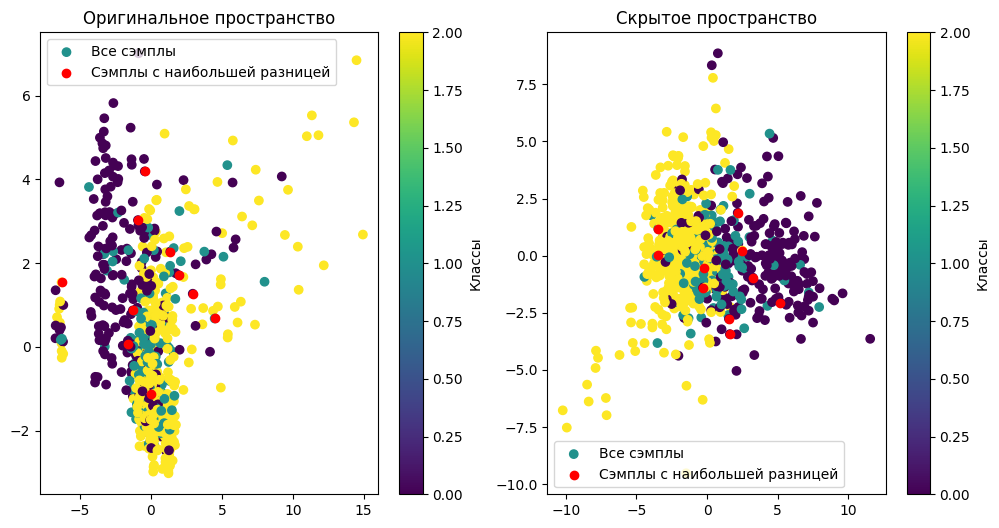

In [128]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train.numpy())
encoded_pca = pca.fit_transform(encoded_X.detach().numpy())

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', label='Все сэмплы')
plt.scatter(X_pca[most_different_samples, 0], X_pca[most_different_samples, 1], c='red', label='Сэмплы с наибольшей разницей')
plt.title("Оригинальное пространство")
plt.legend()
plt.colorbar(scatter, label='Классы')

plt.subplot(1, 2, 2)
scatter = plt.scatter(encoded_pca[:, 0], encoded_pca[:, 1], c=y_train, cmap='viridis', label='Все сэмплы')
plt.scatter(encoded_pca[most_different_samples, 0], encoded_pca[most_different_samples, 1], c='red', label='Сэмплы с наибольшей разницей')
plt.title("Скрытое пространство")
plt.legend()
plt.colorbar(scatter, label='Классы')

plt.show()

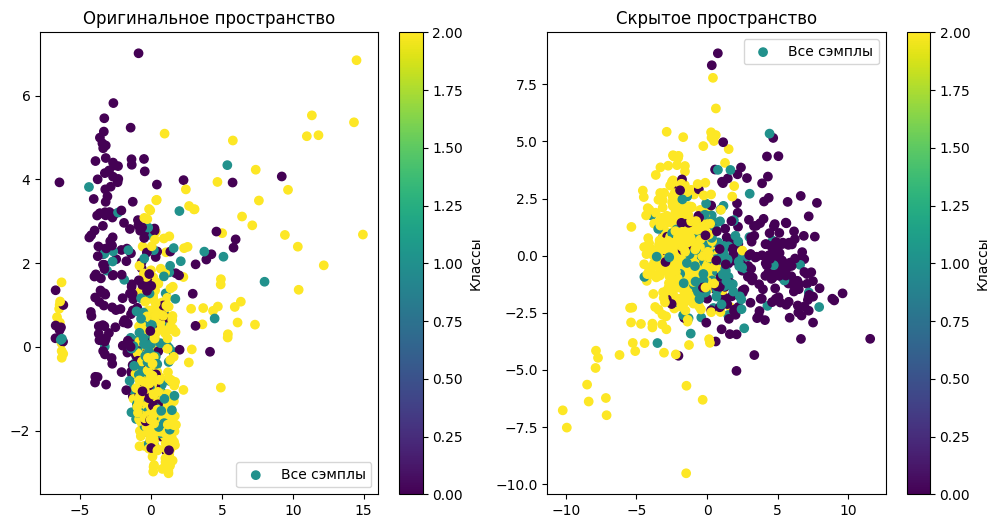

In [129]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', label='Все сэмплы')
plt.title("Оригинальное пространство")
plt.legend()
plt.colorbar(scatter, label='Классы')


plt.subplot(1, 2, 2)
scatter = plt.scatter(encoded_pca[:, 0], encoded_pca[:, 1], c=y_train, cmap='viridis', label='Все сэмплы')
plt.title("Скрытое пространство")
plt.legend()
plt.colorbar(scatter, label='Классы')

plt.show()

по этим графикам - вряд ли сэмплы с наибольшей разницей - выбросы

## Берем второй датасет

In [187]:
fitness = pd.read_csv('fitness.csv')
fitness

,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0
...,...,...,...,...,...,...,...,...
1495,1496,21,79.51,10,Fri,AM,HIIT,0
1496,1497,29,89.55,2,Mon,AM,Strength,0
1497,1498,9,87.38,4,Tue,AM,HIIT,0
1498,1499,34,68.64,14,Sun,AM,Aqua,0


In [188]:
def days_to_num(cell):
    if isinstance(cell, str):
        cell = cell.replace(' days', '')
    return int(cell)

fitness['days_before'] = fitness['days_before'].apply(days_to_num)

In [189]:
df_encoded = fitness.copy()

label_encoders = {}
for column in ['day_of_week', 'time', 'category']:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

X = df_encoded.drop(columns=['booking_id', 'attended']).to_numpy()  # booking_id удаляем, тк это просто номер строки
y = df_encoded['attended'].to_numpy()
X

array([[17.  , 79.56,  8.  ,  8.  ,  1.  ,  4.  ],
       [10.  , 79.01,  2.  ,  2.  ,  0.  ,  3.  ],
       [16.  , 74.53, 14.  ,  5.  ,  0.  ,  4.  ],
       ...,
       [ 9.  , 87.38,  4.  ,  7.  ,  0.  ,  3.  ],
       [34.  , 68.64, 14.  ,  5.  ,  0.  ,  1.  ],
       [20.  , 94.39,  8.  ,  6.  ,  0.  ,  2.  ]])

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=14)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
# np.sum(y_test)

In [194]:
y_train = y_train[~torch.isnan(X_train).any(dim=1)]
X_train = X_train[~torch.isnan(X_train).any(dim=1)]

In [195]:
n_classes = 2

model = TabR(
    n_num_features=X_train.shape[1],
    n_cat_features=0,
    n_classes=n_classes,
    num_embeddings=None,
    d_main=64,
    d_multiplier=2.0,
    encoder_n_blocks=4,  # количество блоков в энкодере
    predictor_n_blocks=4,  # количество блоков в предикторе
    mixer_normalization=True,  # нормализация в модуле поиска
    context_dropout=0.1,  # Dropout для контекста
    dropout0=0.2,
    dropout1=0.1,
    normalization='BatchNorm1d',
    activation='ReLU',
)


optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


epochs = 50

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(
        x_num=X_train,
        x_cat=None,
        y=y_train,
        candidate_x_num=X_train,  # кандидаты для поиска ближайших соседей
        candidate_x_cat=None,
        candidate_y=y_train,  # метки кандидатов
        context_size=32,   # кол-во ближайших соседей
        is_train=True,  # тк обучение
    )

    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()


model.eval()
with torch.no_grad():
    outputs = model(
        x_num=X_test,
        x_cat=None,
        y=None,  # тк предсказание, то метки не нужны
        candidate_x_num=X_train,  # кандидаты для поиска ближайших соседей
        candidate_x_cat=None,
        candidate_y=y_train,  # метки кандидатов
        context_size=32,  # кол-во ближайших соседей
        is_train=False,  # тк предсказание
    )
    y_pred = torch.argmax(outputs, dim=1).numpy()


accuracy = accuracy_score(y_test.numpy(), y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8267


In [196]:

k = 32  # кол-во ближайших соседей
distances_original, orig_indices = get_nearest_neighbors(X_train.numpy(), k, metric='euclidean')
distances_encoded, enc_indices = get_encoded_nearest_neighbors(model, X_train, None, k)
# сравнение соседей
print(f"Среднее совпадение ближайших соседей: {compare_neighbors(orig_indices, enc_indices):.4f}")


Среднее совпадение ближайших соседей: 0.8397


In [198]:
differences = compute_difference(orig_indices, enc_indices)
top_n = 10  # 10 сэмплов с наибольшей разницей
most_different_samples = np.argsort(differences)[-top_n:][::-1]

print(f"Сэмплы с наибольшей разницей между соседями: {most_different_samples}")
print(f"Степень различия для этих сэмплов: {np.array(differences)[most_different_samples]}")

Сэмплы с наибольшей разницей между соседями: [953 103  49 983 752 866 246 251 244 265]
Степень различия для этих сэмплов: [12 12 11 11 11 11 11 11 10 10]


In [202]:
X = df_encoded.drop(columns=['booking_id', 'attended'])
y = df_encoded['attended']
X_train_new, X_test, y_train_new, y_test = train_test_split(X, y, test_size=0.15, random_state=14)


X_train_new['target'] = y_train_new

selected_rows = X_train_new.reset_index(drop=True)
diff_df = selected_rows.loc[most_different_samples]
diff_df[diff_df['target'] == 0]



,months_as_member,weight,days_before,day_of_week,time,category,target
953,8,89.39,7,6,1,3,0
49,16,67.38,2,2,0,3,0
983,8,73.85,3,2,0,4,0
866,13,77.83,2,2,0,1,0
246,21,71.45,2,2,0,3,0
244,12,84.13,29,5,1,4,0
265,4,87.26,2,2,0,5,0


In [206]:
res = selected_rows.drop(most_different_samples).groupby('target').agg(['mean', 'min', 'max'])
res

months_as_member              weight                days_before      \
                   mean min  max       mean    min     max        mean min   
target                                                                       
0             11.618224   1   57  84.877763  55.41  148.02    8.281430   1   
1             24.989950   4  148  76.885620  57.83  121.38    8.585427   1   

           day_of_week              time          category          
       max        mean min max      mean min max      mean min max  
target                                                              
0       16    4.080738   0   9  0.247982   0   1  2.964245   0   5  
1       20    4.095477   0   9  0.206030   0   1  2.967337   1   5

- Можно заметить, что у сэмпла 244 значение `days_before` = 29,хотя максимальное значение у сэмплов нулевого класса этого параметра = 20, то есть этот сэмпл сильно отличается по этому параметру
- Также можно увидеть, что у сэмплов 866 и 265 значение `category` (1 и 5) сильно отклоняется от среднего по выборке остальных сэмплов (около 3)
